In [1]:
# Install des packages 
install.packages(c("tidyverse", "FactoMineR", "factoextra", "corrplot", "caret", "randomForest", "lmtest", "car", "ggrepel", "scales", "viridis", "outliers", "glmnet", "dplyr", "rlang"))

Installation des packages dans 'C:/Users/Younes/AppData/Local/R/win-library/4.6'
(car 'lib' n'est pas spécifié)



package 'tidyverse' successfully unpacked and MD5 sums checked
package 'FactoMineR' successfully unpacked and MD5 sums checked
package 'factoextra' successfully unpacked and MD5 sums checked
package 'corrplot' successfully unpacked and MD5 sums checked
package 'caret' successfully unpacked and MD5 sums checked
package 'randomForest' successfully unpacked and MD5 sums checked
package 'lmtest' successfully unpacked and MD5 sums checked
package 'car' successfully unpacked and MD5 sums checked
package 'ggrepel' successfully unpacked and MD5 sums checked
package 'scales' successfully unpacked and MD5 sums checked
package 'viridis' successfully unpacked and MD5 sums checked
package 'outliers' successfully unpacked and MD5 sums checked
package 'glmnet' successfully unpacked and MD5 sums checked
package 'dplyr' successfully unpacked and MD5 sums checked
package 'rlang' successfully unpacked and MD5 sums checked


Warning message:
"impossible de supprimer l'installation précédente du package 'rlang'"
Warning message in file.copy(savedcopy, lib, recursive = TRUE):
"problème lors de la copie de C:\Users\Younes\AppData\Local\R\win-library\4.6\00LOCK\rlang\libs\x64\rlang.dll vers C:\Users\Younes\AppData\Local\R\win-library\4.6\rlang\libs\x64\rlang.dll : Permission denied"
Warning message:
"'rlang' restauré"



Les packages binaires téléchargés sont dans
	C:\Users\Younes\AppData\Local\Temp\RtmpwBBuys\downloaded_packages


In [2]:
install.packages("plotly")

Installation du package dans 'C:/Users/Younes/AppData/Local/R/win-library/4.6'
(car 'lib' n'est pas spécifié)



package 'plotly' successfully unpacked and MD5 sums checked

Les packages binaires téléchargés sont dans
	C:\Users\Younes\AppData\Local\Temp\RtmpwBBuys\downloaded_packages


In [3]:
install.packages("ggplot2")
install.packages("ggplot")

Installation du package dans 'C:/Users/Younes/AppData/Local/R/win-library/4.6'
(car 'lib' n'est pas spécifié)



package 'ggplot2' successfully unpacked and MD5 sums checked

Les packages binaires téléchargés sont dans
	C:\Users\Younes\AppData\Local\Temp\RtmpwBBuys\downloaded_packages


Installation du package dans 'C:/Users/Younes/AppData/Local/R/win-library/4.6'
(car 'lib' n'est pas spécifié)

Warning message:
"le package 'ggplot' n'est pas disponible for this version of R

Une version de ce package pour votre version de R est peut-être disponible ailleurs,
Voyez des idées à
https://cran.r-project.org/doc/manuals/r-patched/R-admin.html#Installing-packages"


In [1]:

library(tidyverse)
library(FactoMineR)
library(factoextra)
library(corrplot)
library(caret)
library(randomForest)
library(lmtest)
library(car)
library(ggrepel)
library(scales)
library(viridis)
library(outliers)
library(glmnet)
library(dplyr)
library(corrplot)
library(ggplot2)
library(plotly)

── Attaching core tidyverse packages ──────────────────────── tidyverse 2.0.0 ──
✔ dplyr     1.2.1     ✔ readr     2.2.0
✔ forcats   1.0.1     ✔ stringr   1.6.0
✔ ggplot2   4.0.3     ✔ tibble    3.3.1
✔ lubridate 1.9.5     ✔ tidyr     1.3.2
✔ purrr     1.2.2     
── Conflicts ────────────────────────────────────────── tidyverse_conflicts() ──
✖ dplyr::filter() masks stats::filter()
✖ dplyr::lag()    masks stats::lag()
ℹ Use the conflicted package (<http://conflicted.r-lib.org/>) to force all conflicts to become errors
Welcome to factoextra!

Want to learn more? See two factoextra-related books at https://www.datanovia.com/en/product/practical-guide-to-principal-component-methods-in-r/

corrplot 0.95 loaded

Le chargement a nécessité le package : lattice


Attachement du package : 'caret'


L'objet suivant est masqué depuis 'package:purrr':

    lift


randomForest 4.7-1.2

Type rfNews() to see new features/changes/bug fixes.


Attachement du package : 'randomForest'


L'objet suivant e

# Quels sont les facteurs associés au succès commercial d'un jeu ?

## Définir le succès commercial

In [2]:
df <- read_csv("clean.csv")

Warning message:
"One or more parsing issues, call `problems()` on your data frame for details,
e.g.:
  dat <- vroom(...)
  problems(dat)"
Rows: 113121 Columns: 37
── Column specification ────────────────────────────────────────────────────────
Delimiter: ","
chr (10): Name, Release date, Estimated owners, Supported languages, Full au...
dbl (23): AppID, Peak CCU, Required age, Price, Discount, DLC count, Reviews...
lgl  (4): Windows, Mac, Linux, Score rank

ℹ Use `spec()` to retrieve the full column specification for this data.
ℹ Specify the column types or set `show_col_types = FALSE` to quiet this message.


### Transformations des features du dataset pour préparer notre variable success_score

In [3]:
df_clean <- df %>%

  select(-`Score rank`, -`User score`) %>%
  
  
  mutate(
    total_reviews = ifelse(`Ratio positive vote` > 0 & !is.na(`Ratio positive vote`),
                           round(Positive / `Ratio positive vote`),
                           Positive),  # si ratio NA, on a 0 négatifs
    Negative = total_reviews - Positive
  ) %>%
  
  # mediane des owners pour tout le monde
  mutate(
    owners_low  = as.numeric(str_extract(`Estimated owners`, "^[0-9]+")),
    owners_high = as.numeric(str_extract(`Estimated owners`, "[0-9]+$")),
    owners_midpoint = (owners_low + owners_high) / 2
  ) %>%
  
  
  mutate(
    nb_languages = str_count(`Supported languages`, ",") + 1
  ) %>%
  
  
  mutate(
    log_owners          = log1p(owners_midpoint),
    log_recommendations = log1p(Recommendations),
    log_peak_ccu        = log1p(`Peak CCU`),
    log_median_playtime = log1p(`Median playtime forever`)
  )


### Évaluation de la fiabilité des ratings avec le Wilson Score

In [4]:
wilson_score <- function(positive, negative, z = 1.96) {
  n <- positive + negative
  if (n == 0) return(NA)
  p_hat <- positive / n
  numerator   <- p_hat + z^2/(2*n) - z * sqrt(p_hat*(1-p_hat)/n + z^2/(4*n^2))
  denominator <- 1 + z^2/n
  return(numerator / denominator)
}

df_clean <- df_clean %>%
  mutate(
    wilson = mapply(wilson_score, Positive, Negative)
  )

### Création de la variable sucess_score

In [5]:
df_clean <- df_clean %>%
  mutate(
    success_score = 0.5 * log_owners +
                    0.3 * log_recommendations +
                    0.2 * wilson
  )

In [6]:
# Réinitialiser le système graphique
if (!is.null(dev.list())) dev.off()
options(device = function(...) cairo_pdf(tempfile(fileext = ".pdf")))

null device 
          1

Visualisation de la distribution du score de succès commercial selon les jeux

Warning message:
"Removed 33643 rows containing non-finite outside the scale range
(`stat_bin()`)."


[1] 1493

Name,success_score,log_owners,log_recommendations,wilson
<chr>,<dbl>,<dbl>,<dbl>,<dbl>
Counter-Strike 2,14.20355,18.82615,15.39045,0.8667080
PUBG: BATTLEGROUNDS,13.84493,18.82615,14.37699,0.5938040
Grand Theft Auto V Legacy,13.57113,18.13300,14.43300,0.8736560
Black Myth: Wukong,13.36022,18.13300,13.66820,0.9663009
Left 4 Dead 2,13.32811,18.13300,13.55535,0.9750388
Palworld,13.07861,18.13300,12.74684,0.9402968
Terraria,13.07030,17.37086,13.96652,0.9745576
Tom Clancy's Rainbow Six® Siege X,13.05828,17.37086,14.01752,0.8379904
Call of Duty®,13.05575,18.13300,12.90656,0.5864306


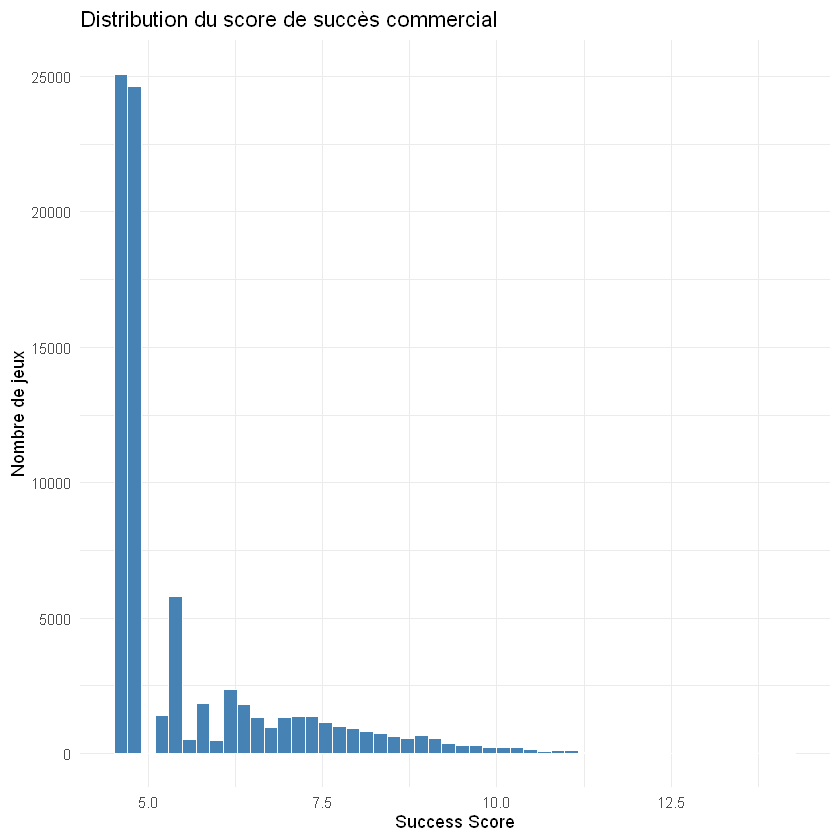

In [6]:
ggplot(df_clean, aes(x = success_score)) +
  geom_histogram(bins = 50, fill = "steelblue", color = "white") +
  labs(title = "Distribution du score de succès commercial",
       x = "Success Score", y = "Nombre de jeux") +
  theme_minimal()

# idd les outliers 
df_clean <- df_clean %>%
  mutate(
    success_zscore = scale(success_score)[,1],
    is_outlier = abs(success_zscore) > 3
  )

# combien d'outliers 
sum(df_clean$is_outlier, na.rm = TRUE)

df_clean %>%
  filter(is_outlier) %>%
  select(Name, success_score, log_owners, log_recommendations, wilson) %>%
  arrange(desc(success_score)) %>%
  head(20)


Score pour Jusant par exemple (bon score qui reflète un bon succès en réalité bien que le jeu soit indie et possède bien moins de joueurs qu'un AAA) le score le prend en compte. 

In [7]:
df_clean %>%
  filter(str_detect(Name, "Jusant")) %>%
  select(Name, success_score, log_owners, log_recommendations, 
         wilson, owners_midpoint, Positive, Negative)

Name,success_score,log_owners,log_recommendations,wilson,owners_midpoint,Positive,Negative
<chr>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
Jusant,9.02752,12.76569,8.200014,0.9233531,350000,4649,346


# Quels facteurs sont associés au succès commercial
### Visualisation des corrélations entre variables avec un corrplot afin pour avoir une première idée des relations avec le succès commercial.

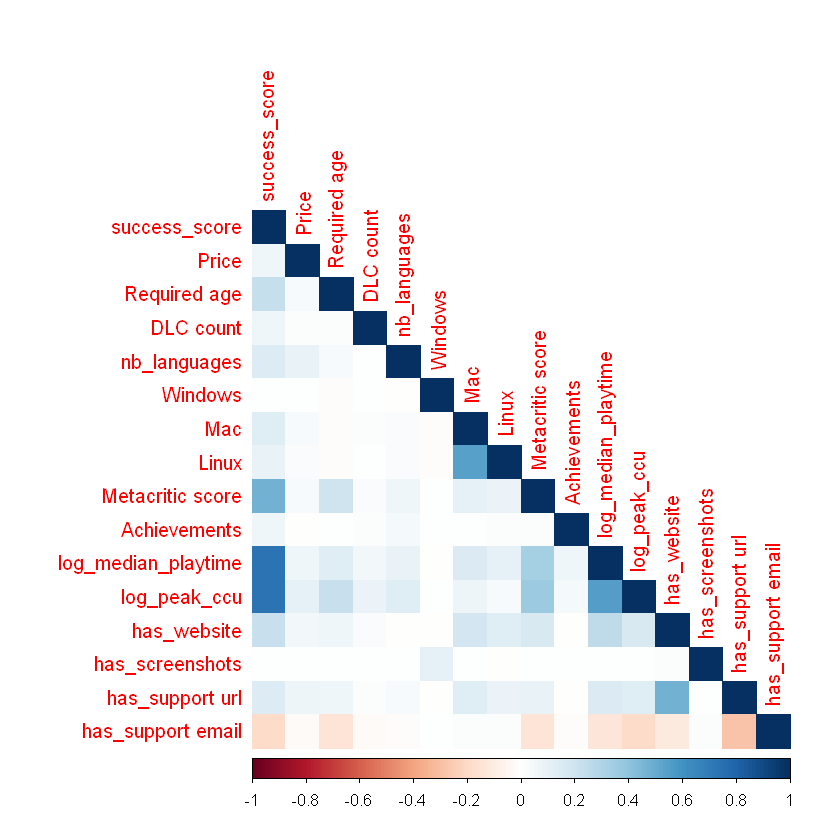

In [11]:
#lancer Lasso (cell suivante) puis celle ci
cor_matrix <- cor(data_model)
corrplot(cor_matrix, method = "color", type = "lower")

### Modèle LASSO plus robuste pour déterminer ces facteurs

                       lambda.min
log_peak_ccu         0.4662036525
log_median_playtime  0.2379225180
Windows              0.1189400920
has_screenshots      0.0854325894
has_support email   -0.0831083557
Linux                0.0465094792
Mac                  0.0356863879
Required age         0.0312168247
has_website          0.0276379844
Metacritic score     0.0135244090
has_support url     -0.0133570539
nb_languages         0.0041650290
Price               -0.0025416720
Achievements         0.0001334923
DLC count            0.0000000000


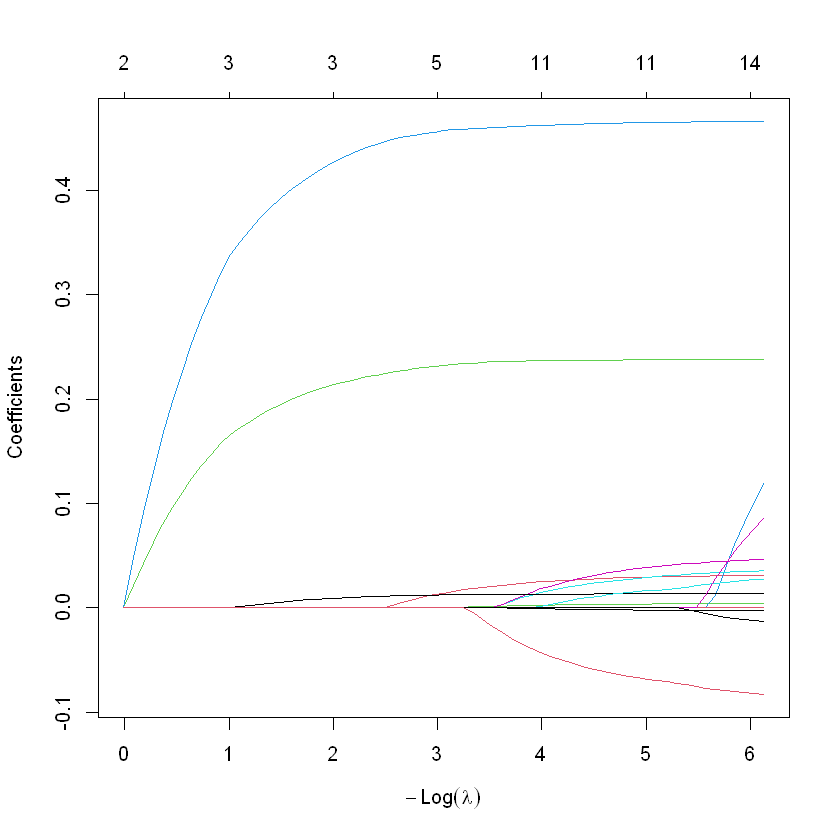

In [8]:
data_model <- df_clean %>%
  select(
    success_score,
    Price, `Required age`, `DLC count`,
    nb_languages, Windows, Mac, Linux,
    `Metacritic score`, Achievements,
    log_median_playtime, log_peak_ccu,
    has_website, has_screenshots,
    `has_support url`, `has_support email`
  ) %>%
  mutate(across(where(is.logical), as.numeric)) %>%
  drop_na()

X <- data.matrix(data_model %>% select(-success_score))
y <- data_model$success_score
set.seed(42)

lasso_cv <- cv.glmnet(
  X, y,
  alpha = 1,        # LASSO
  standardize = TRUE
)

set.seed(42)

lasso_cv <- cv.glmnet(
  X, y,
  alpha = 1,
  standardize = TRUE
)

plot(lasso_cv$glmnet.fit, xvar = "lambda")

coef_lasso <- coef(lasso_cv, s = "lambda.min")




important_vars <- coef_lasso[-1, , drop = FALSE]  # enlever l'intercept
important_vars <- as.matrix(important_vars)
important_vars <- important_vars[order(abs(important_vars[,1]), decreasing = TRUE), , drop = FALSE]


print(important_vars)

# Validation et structure du success_score

## Valider que le success_score capture une structure réelle

Avant d'analyser les facteurs, nous devons confirmer que notre score composite (0.5 * log_owners + 0.3 * log_recommendations + 0.2 * wilson) a du sens et synthétise correctement les trois composantes.

VIF (Variance Inflation Factor) :
         log_owners log_recommendations              wilson 
           1.818065            2.105111            1.320155 


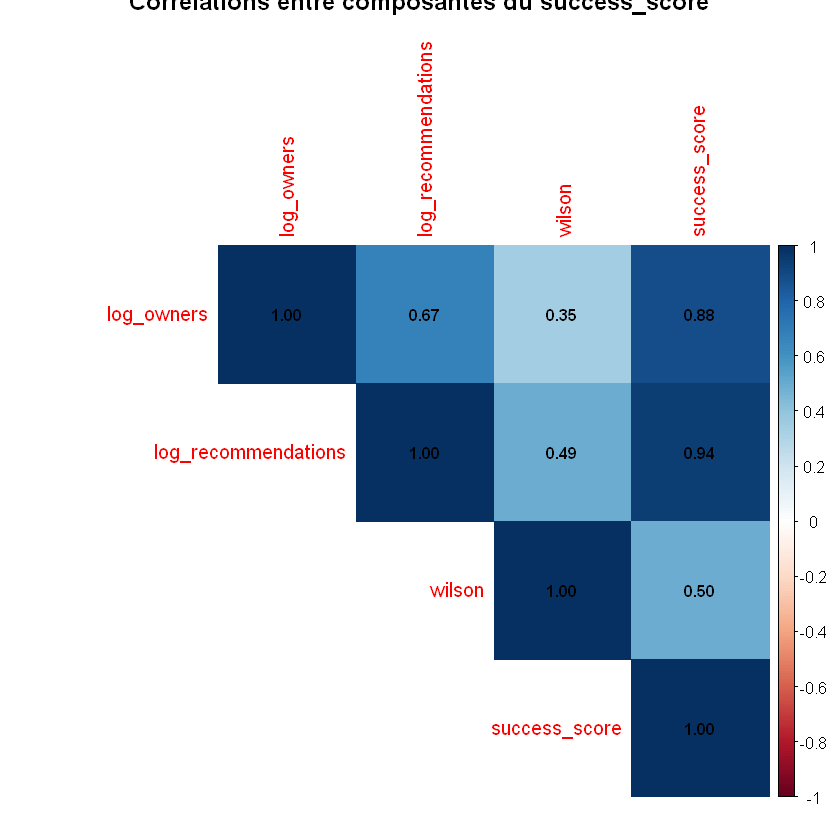

In [9]:
#Corrélations et structure des composantes


success_components <- df_clean %>%
  select(log_owners, log_recommendations, wilson, success_score) %>%
  drop_na()


cor_components <- cor(success_components)
corrplot(cor_components, method = "color", type = "upper", 
         addCoef.col = "black", number.cex = 0.8,
         title = "Corrélations entre composantes du success_score")

# VIF pour vérifier la multicollinéarité
library(car)
fit_components <- lm(success_score ~ log_owners + log_recommendations + wilson, 
                     data = success_components)
cat("VIF (Variance Inflation Factor) :\n")
print(vif(fit_components))


Les 3 variables ne sont pas des copies exactes mais elles vont globalement dans le même sens donc les combiner est cohérent.

Le VIF nous indique très peu de multicolinéarité ( <5 pour chacunes des variables), les variables ne sont pas redondantes donc chacune apporte une information distincte.

VARIANCE EXPLIQUÉE PAR CHAQUE COMPOSANTE PRINCIPALE
     PC Variance Cumulative
1   PC1   0.2298     0.2298
2   PC2   0.1108     0.3406
3   PC3   0.0794     0.4200
4   PC4   0.0764     0.4964
5   PC5   0.0728     0.5693
6   PC6   0.0709     0.6401
7   PC7   0.0662     0.7063
8   PC8   0.0655     0.7718
9   PC9   0.0632     0.8350
10 PC10   0.0594     0.8944
11 PC11   0.0333     0.9277
12 PC12   0.0321     0.9599
13 PC13   0.0231     0.9829
14 PC14   0.0171     1.0000

Poids des variables sur les PC
                       PC1    PC2    PC3    PC4    PC5    PC6    PC7    PC8
log_owners          -0.462  0.104 -0.006 -0.113  0.032 -0.046  0.096 -0.036
log_recommendations -0.489  0.105  0.004 -0.020  0.019 -0.041  0.093  0.064
log_peak_ccu        -0.456  0.158 -0.002  0.009 -0.015  0.017  0.069 -0.005
log_median_playtime -0.456  0.033  0.007 -0.073  0.025 -0.039  0.098  0.164
Achievements        -0.053  0.029  0.014  0.172  0.803 -0.218 -0.492  0.160
Price               -0.074 -0.024  0.025

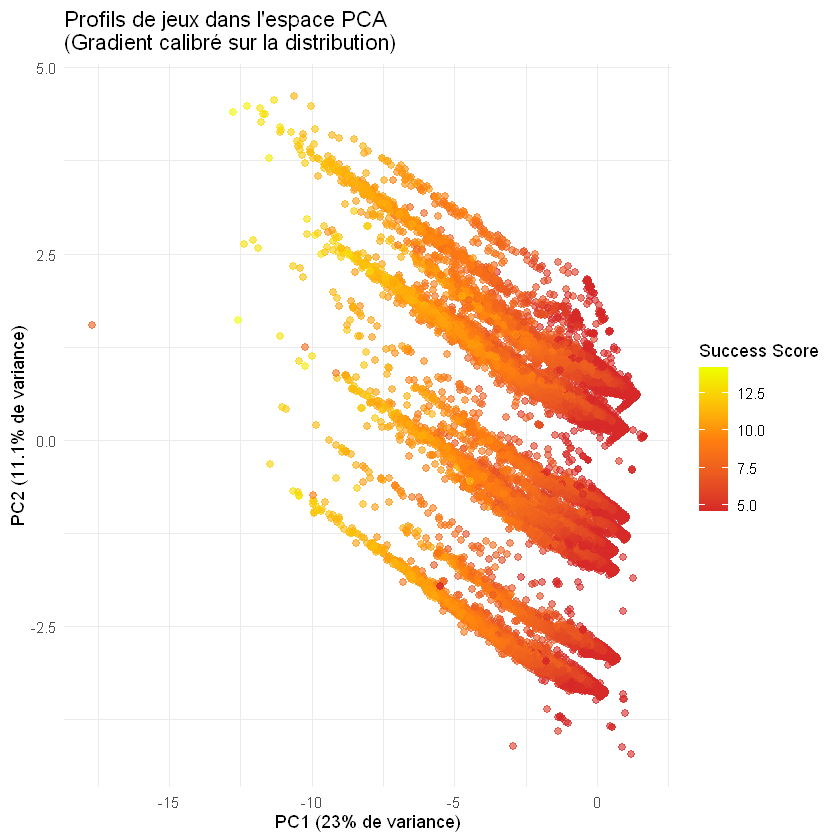

In [10]:
### 2. PCA sur les 3 composantes : Valider la structure sous-jacente

# Normaliser les composantes

base_pca <- df_clean %>%
  select(
    log_owners, log_recommendations, log_peak_ccu,
    log_median_playtime, Achievements,
    Price, `DLC count`, nb_languages, `Required age`, has_screenshots, has_website,
    Windows, Mac, Linux,
    wilson, success_score
  ) %>%
  drop_na()

# Scale sans success_score et wilson
success_scaled <- base_pca %>%
  select(-success_score, -wilson) %>%
  mutate(across(everything(), scale)) %>%
  as.matrix()

# PCA
pca_success <- prcomp(success_scaled)

# Variance expliquée
pca_var <- pca_success$sdev^2 / sum(pca_success$sdev^2)
cumsum_var <- cumsum(pca_var)

cat("VARIANCE EXPLIQUÉE PAR CHAQUE COMPOSANTE PRINCIPALE\n")
print(data.frame(
  PC = paste0("PC", 1:length(pca_var)),
  Variance = round(pca_var, 4),
  Cumulative = round(cumsum_var, 4)
))

# Scores PCA alignés
pca_scores <- data.frame(
  PC1 = pca_success$x[, 1],
  PC2 = pca_success$x[, 2],
  success_score = base_pca$success_score
)

# Graphique


pca_scores <- pca_scores %>%
  mutate(success_cat = case_when(
    success_score < quantile(success_score, 0.33) ~ "Faible",
    success_score < quantile(success_score, 0.66) ~ "Moyen",
    TRUE ~ "Fort"
  ))




quantiles <- quantile(pca_scores$success_score, probs = c(0, 0.33, 0.66, 1))

ggplot(pca_scores, aes(x = PC1, y = PC2, color = success_score)) +
  geom_point(size = 2, alpha = 0.6) +
  scale_color_gradientn(
  colors = c("#d62728", "#ff7f0e", "#eeff00"),
  name = "Success Score"
) +
  labs(
    title = "Profils de jeux dans l'espace PCA\n(Gradient calibré sur la distribution)",
    x = paste0("PC1 (", round(pca_var[1]*100, 1), "% de variance)"),
    y = paste0("PC2 (", round(pca_var[2]*100, 1), "% de variance)"),
  ) +
  theme_minimal()  

# Loadings
cat("\nPoids des variables sur les PC\n")
print(round(pca_success$rotation, 3))




L'ACP est réalisée sur les features des jeux (prix, playtime, langues, DLC, présence en ligne...)
et non sur les 3 composantes du `success_score` (`log_owners`, `log_recommendations`, `wilson`).
Faire une ACP sur ces 3 variables aurait été redondant : la structure trouvée n'aurait fait 
que refléter la formule `0.5×log_owners + 0.3×log_reco + 0.2×wilson`.

Ici, l'ACP ignore le succès et cherche les dimensions de variance naturelle des jeux.
PC1 (23% de variance) capte un axe global de présence commerciale : les jeux à gauche 
ont plus d'owners, de recommendations et de playtime. Le gradient rouge-jaune suit 
cet axe, les jeux les plus réussis occupent naturellement le côté gauche 
de PC1**, sans que le score de succès ait influencé l'ACP.

Cela valide que le `success_score` n'est pas totalement arbitraire : il discrimine une dimension 
qui existe réellement dans les données.

## Robustesse du score

CORRÉLATION DES RANGS ENTRE SCÉNARIOS (Spearman)
robustesse : proche de 1 = stable, proche de 0 = instable

              rank_original rank_equal rank_owners rank_quality rank_balanced
rank_original         1.000      0.826       0.957        0.730         0.970
rank_equal            0.826      1.000       0.665        0.971         0.898
rank_owners           0.957      0.665       1.000        0.555         0.883
rank_quality          0.730      0.971       0.555        1.000         0.819
rank_balanced         0.970      0.898       0.883        0.819         1.000


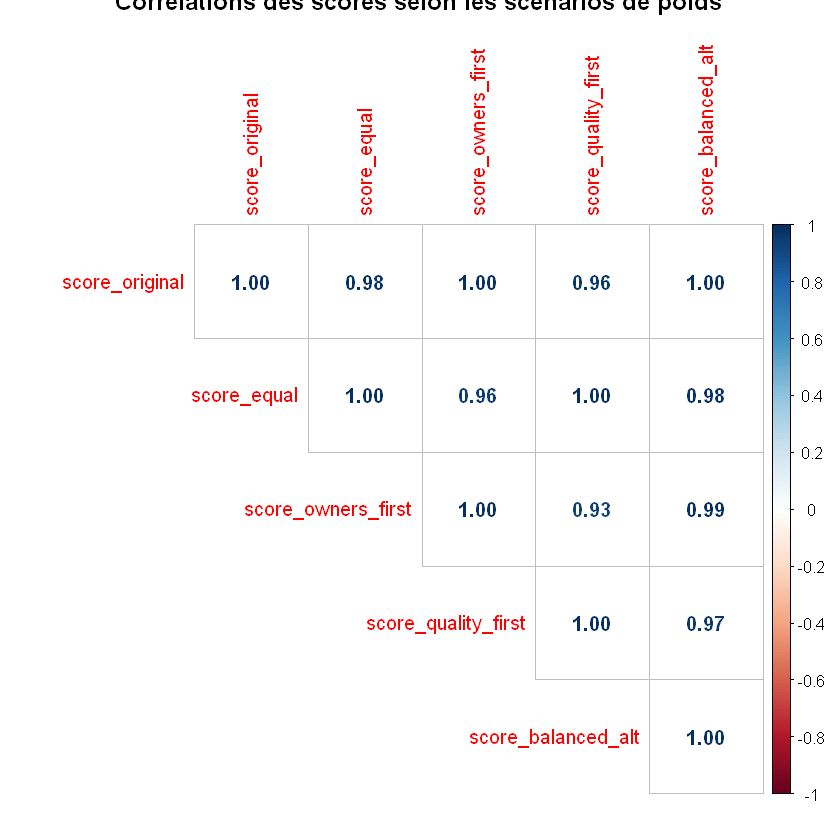

In [11]:



success_norm <- success_components %>%
  mutate(
    log_owners_norm = scale(log_owners)[,1],
    recomm_norm = scale(log_recommendations)[,1],
    wilson_norm = scale(wilson)[,1]
  )

# plusieurs scénarios de poids
weight_scenarios <- list(
  original = c(0.50, 0.30, 0.20),    
  equal = c(0.333, 0.333, 0.333),    
  owners_first = c(0.60, 0.25, 0.15), 
  quality_first = c(0.30, 0.30, 0.40), 
  balanced_alt = c(0.45, 0.35, 0.20)  
)

#scores avec chaque scénario 
for (scenario in names(weight_scenarios)) {
  w <- weight_scenarios[[scenario]]
  success_norm[[paste0("score_", scenario)]] <- 
    w[1] * success_norm$log_owners_norm + 
    w[2] * success_norm$recomm_norm + 
    w[3] * success_norm$wilson_norm
}

#classements des TOP 50 jeux
top_games <- success_norm %>%
  select(Name = log_owners, contains("score_")) %>%  # Garder des identifiants
  arrange(desc(score_original)) %>%
  head(50) %>%
  mutate(
    rank_original = row_number(),
    rank_equal = rank(desc(score_equal)),
    rank_owners = rank(desc(score_owners_first)),
    rank_quality = rank(desc(score_quality_first)),
    rank_balanced = rank(desc(score_balanced_alt))
  )

rank_cols <- c("rank_original", "rank_equal", "rank_owners", "rank_quality", "rank_balanced")
rank_corr <- cor(top_games[rank_cols], method = "spearman")

cat("CORRÉLATION DES RANGS ENTRE SCÉNARIOS (Spearman)\n")
cat("robustesse : proche de 1 = stable, proche de 0 = instable\n\n")
print(round(rank_corr, 3))


score_cols <- c("score_original", "score_equal", "score_owners_first", "score_quality_first", "score_balanced_alt")
score_corr_matrix <- cor(success_norm[score_cols], use = "complete.obs")

corrplot(score_corr_matrix, method = "number", type = "upper", 
         title = "Corrélations des scores selon les scénarios de poids")



Cinq scénarios de pondération des poids ont été testés pour évaluer la stabilité du `success_score` :
pondération originale (0.5/0.3/0.2), égale, centrée sur les owners, centrée 
sur la qualité, et équilibrée. La corrélation de Spearman entre les rangs produits 
par ces scénarios est mesurée, proche de 1 signifie que peu importe les poids choisis, 
les mêmes jeux ressortent en tête.

La corrélation moyenne entre tous les scénarios est de 0.977, au-dessus du seuil de 0.95.
Les scénarios les plus divergents sont rank_owners vs rank_quality (0.555), ce qui est 
attendu car maximiser les owners et maximiser la qualité mesurent des choses 
différentes. Mais notre score original reste très corrélé à tous les autres (min 0.730).

Le classement des jeux est donc stable car changer les pondérations ne changera pas 
les conclusions. Le success_score est bien robuste !

# Analyses des facteurs associés au succès : approche robuste

## Préparer les données pour les tests

Nous allons tester directement chaque facteur contre success_score (pas ses composantes individuelles).

# Décomposer les mécanismes du succès

Les tests univariés montrent quels facteurs comptent. Comment fonctionnent-ils exactement ?
Les effets sont-ils contextuels ? Des archétypes ? Les causalités sont-elles directes ou indirectes ?

EFFET DU DLC SELON LA CATÉGORIE DE PRIX

Gratuit (n=8265) :
  Médiane avec DLC: 5.42 | sans DLC: 4.76 | Différence: 0.66
  p-value: 0.0000 | Significatif?: OUI

Budget (n=63056) :
  Médiane avec DLC: 6.29 | sans DLC: 4.73 | Différence: 1.56
  p-value: 0.0000 | Significatif?: OUI

Premium (n=8157) :
  Médiane avec DLC: 7.39 | sans DLC: 4.74 | Différence: 2.64
  p-value: 0.0000 | Significatif?: OUI


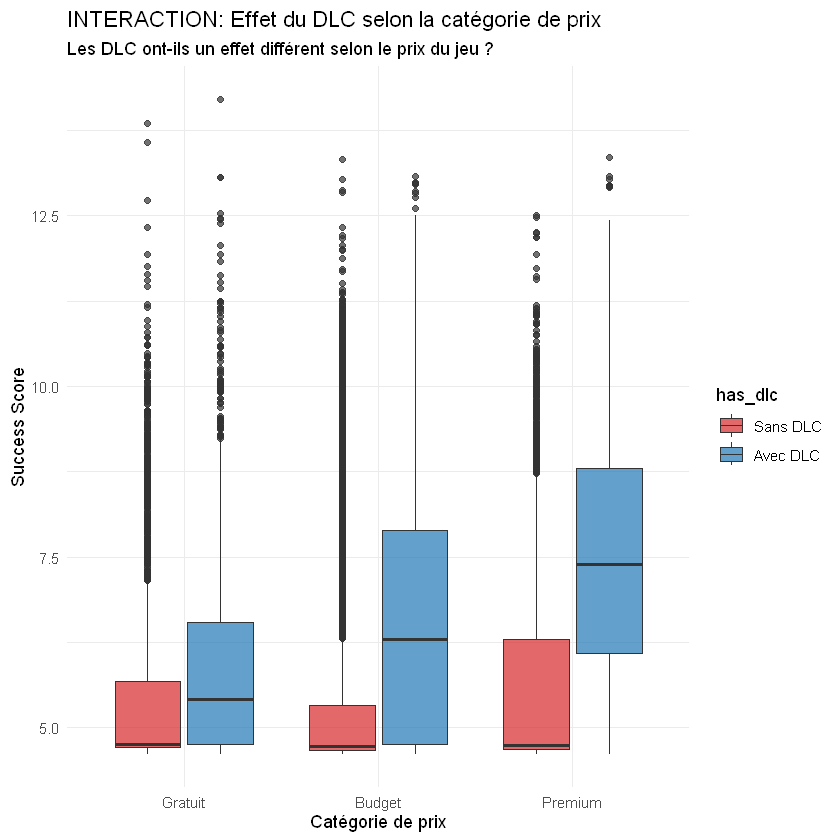

In [12]:


# Hypothèse : les DLC aident surtout les jeux premium (où les joueurs attendent du contenu en plus)
# mais pas les gratuits (où les joueurs ne paieront pas pour des extras alors qu'ils ont joué gratuitement à la base)

df_analysis <- df_clean %>%
  select(success_score, Price, `DLC count`) %>%
  drop_na()

#groupes de prix  
df_analysis <- df_analysis %>%
  mutate(
    has_dlc = `DLC count` > 0,
    price_category = case_when(
      Price == 0 ~ "Gratuit",
      Price < 10 ~ "Budget",
      Price >= 10 ~ "Premium"
    ) %>% factor(levels = c("Gratuit", "Budget", "Premium"))
  )

# 
cat("EFFET DU DLC SELON LA CATÉGORIE DE PRIX\n")
for (cat in levels(df_analysis$price_category)) {
  subset_data <- df_analysis %>% filter(price_category == cat)
  test_result <- wilcox.test(success_score ~ has_dlc, data = subset_data)
  
  median_with_dlc <- median(subset_data$success_score[subset_data$has_dlc == TRUE], na.rm = TRUE)
  median_no_dlc <- median(subset_data$success_score[subset_data$has_dlc == FALSE], na.rm = TRUE)
  
  cat(sprintf("\n%s (n=%d) :\n", cat, nrow(subset_data)))
  cat(sprintf("  Médiane avec DLC: %.2f | sans DLC: %.2f | Différence: %.2f\n", 
              median_with_dlc, median_no_dlc, median_with_dlc - median_no_dlc))
  cat(sprintf("  p-value: %.4f | Significatif?: %s\n", 
              test_result$p.value, ifelse(test_result$p.value < 0.05, "OUI", "NON")))
}

p_interaction <- df_analysis %>%
  filter(!is.na(success_score), !is.na(has_dlc)) %>%
  ggplot(aes(x = price_category, y = success_score, fill = has_dlc)) +
  geom_boxplot(alpha = 0.7) +
  scale_fill_manual(values = c("FALSE" = "#d62728", "TRUE" = "#1f77b4"),
                    labels = c("FALSE" = "Sans DLC", "TRUE" = "Avec DLC")) +
  labs(title = "INTERACTION: Effet du DLC selon la catégorie de prix",
       x = "Catégorie de prix",
       y = "Success Score",
       subtitle = "Les DLC ont-ils un effet différent selon le prix du jeu ?") +
  theme_minimal() +
  theme(legend.position = "right")

print(p_interaction)



L'effet des DLC sur le succès n'est pas uniforme, il s'amplifie avec le prix du jeu.
Sur les jeux gratuits, la différence de médiane entre jeux avec et sans DLC est de +0.66,
modeste mais significative. Elle monte à +1.56 pour les jeux budget, et atteint +2.64 
pour les jeux premium.

Les DLC ont d'autant plus d'impact que le jeu est cher, ce qui suggère 
que sur les jeux premium, les joueurs qui achètent sont déjà engagés donc plus susceptibles à 
consommer du contenu additionnel (ils n'ont pas eu de problèmes à payer le jeu à la base). À l'inverse sur les jeux gratuits, la barrière à l'entrée 
est nulle et les DLC peinent.

Dans les trois catégories, l'effet est significatif.

## Identification des archétypes de succès via Clustering

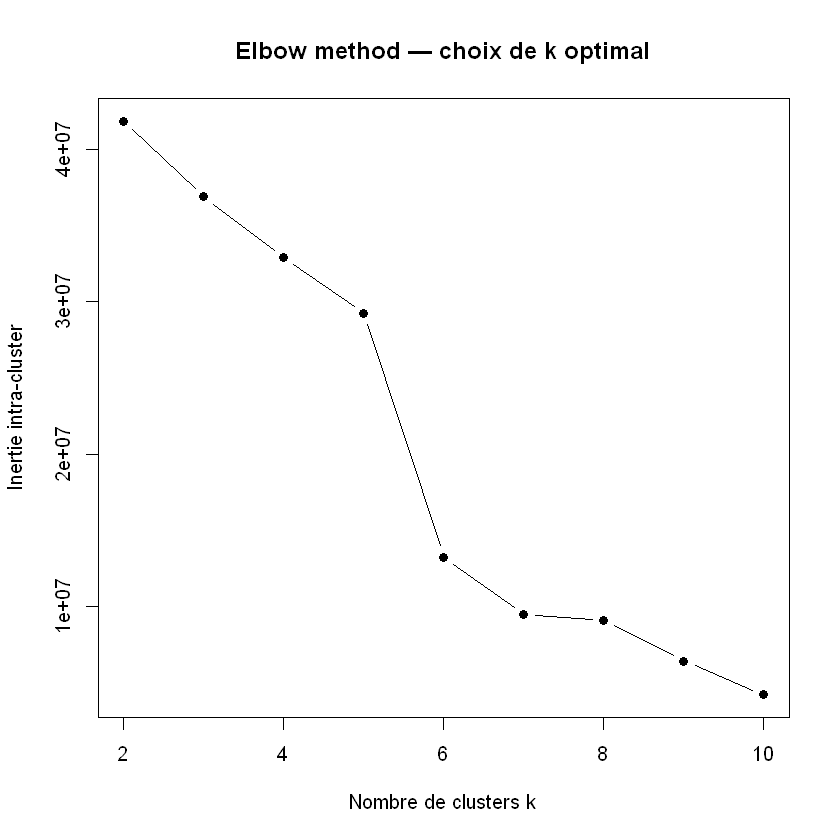

In [ ]:

wss <- sapply(2:10, function(k) {
  clusters_k <- cutree(hc, k = k)
  sum(sapply(unique(clusters_k), function(c) {
    sum(dist(df_cluster_norm[clusters_k == c, ])^2)
  }))
})

plot(2:10, wss, type = "b", pch = 19,
     xlab = "Nombre de clusters k",
     ylab = "Inertie intra-cluster",
     main = "Elbow method — choix de k optimal")

# A tibble: 5 × 7
  cluster     n score_med owners_med wilson_med dlc_mean price_mean
    <int> <int>     <dbl>      <dbl>      <dbl>    <dbl>      <dbl>
1       2  1154      7.33      11.2       0.794   0.462        5.43
2       5   139      6.98      11.2       0.773   4.33         5.61
3       3  1708      4.75       9.21      0.676   0.0984       2.70
4       4   333      4.71       9.21      0.512   0.279       17.1 
5       1  1666      4.68       9.21      0.342   0.0750       3.41


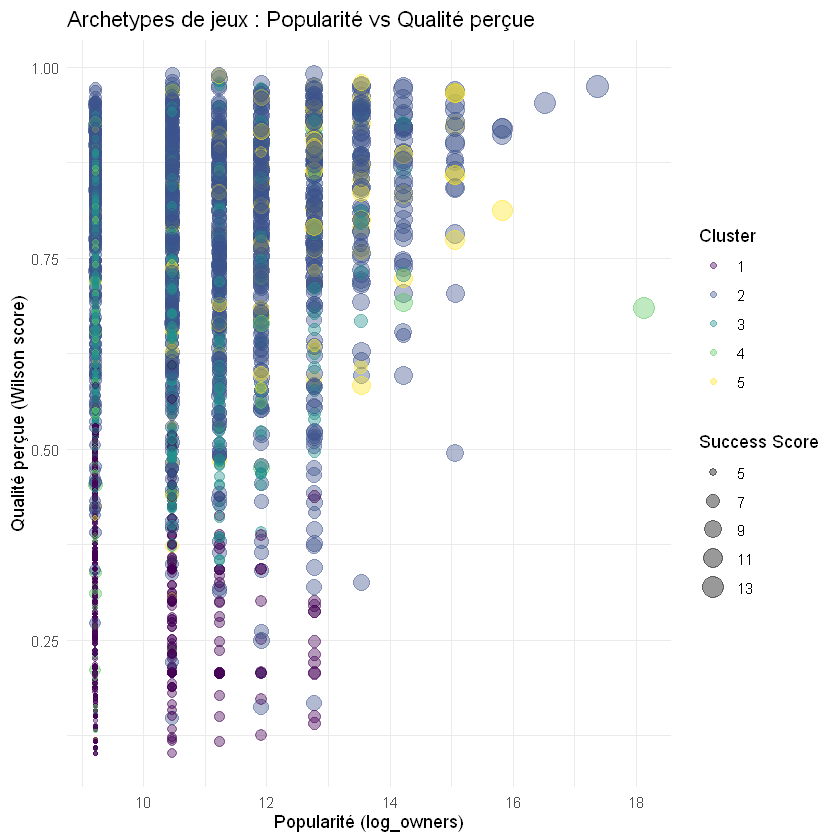

In [ ]:

df_cluster_data <- df_clean %>%
  select(log_owners, log_recommendations, wilson, success_score,
         dlc_count = `DLC count`, Price, Achievements) %>%
  drop_na() %>%
 filter(
    Price < 60,
    Achievements < 500,
    wilson > 0.1,
    dlc_count < 10
  )

# Echantillon de 5000 max sinon c trop
set.seed(42)
sample_idx <- sample(nrow(df_cluster_data), min(5000, nrow(df_cluster_data)))
df_cluster_sample <- df_cluster_data[sample_idx, ]


df_cluster_norm <- df_cluster_sample %>%
  select(-success_score) %>%
  mutate(across(everything(), scale))

# Clustering
hc <- hclust(dist(df_cluster_norm), method = "ward.D2")
clusters <- cutree(hc, k = 5)


cluster_profiles <- data.frame(
  cluster = clusters,
  df_cluster_sample
) %>%
  group_by(cluster) %>%
  summarise(
    n = n(),
    score_med = median(success_score),
    owners_med = median(log_owners),
    wilson_med = median(wilson),
    dlc_mean = mean(dlc_count),
    price_mean = mean(Price),
    .groups = 'drop'
  ) %>%
  arrange(desc(score_med))

print(cluster_profiles)


data.frame(
  cluster = factor(clusters),
  log_owners = df_cluster_sample$log_owners,
  wilson = df_cluster_sample$wilson,
  score = df_cluster_sample$success_score
) %>%
  ggplot(aes(x = log_owners, y = wilson, color = cluster, size = score)) +
  geom_point(alpha = 0.4) +
  scale_color_viridis_d(name = "Cluster") +
  scale_size_continuous(name = "Success Score") +
  labs(
    title = "Archetypes de jeux : Popularité vs Qualité perçue",
    x = "Popularité (log_owners)",
    y = "Qualité perçue (Wilson score)"
  ) +
  theme_minimal()

# Analyse des archétypes de succès

#### Les clusters sur le graphique

X (Popularité) : faible variation entre clusters
- Cluster 1, 3, 4 : tous à ~9.2 (log owners)
- Cluster 2, 5 : 11.2 (légèrement plus haut)

Y (Qualité) : forte variation entre clusters
- Cluster 1 : 0.34 (faible)
- Cluster 4 : 0.51 (moyen-faible)
- Cluster 3 : 0.68 (moyen)
- Cluster 2, 5 : 0.77-0.79 (élevé)

Taille des bulles : Le success_score augmente avec la qualité (Y)

### Discriminant

La qualité perçue est le facteur qui différencie le mieux les clusters.
La popularité brute varie peu d'un groupe à l'autre.

### Trois profils distincts

| Stratégie | Cluster | Profil | Success Score |
|-----------|---------|--------|---------------|
| Quality focus | Cluster 2 | Excellente qualité (0.79) + prix accessible (5.43€) | 7.33 |
| Quality + DLC | Cluster 5 | Très bonne qualité (0.77) + monétisation DLC (4.33) | 6.98 |
| Price Wars | Cluster 1 | Qualité faible (0.34) + prix bas (3.41€) | 4.68 |

### Conclusion

Les clusters montrent que la qualité perçue est associée à un meilleur success_score,
indépendamment du prix. Le prix seul ne suffit pas à compenser une qualité faible
le Cluster 4 (17.1€, wilson 0.51) obtient le même score que le Cluster 1 (3.41€, wilson 0.34).

# Tests univariés pour vérifier que chaque facteur influence vraiment le succès.

In [16]:
### Préparer df_analysis avec success_score

df_analysis <- df_clean %>%
  mutate(
    has_dlc = `DLC count` > 0,
    price_group = case_when(
      Price == 0 ~ "Gratuit",
      Price < 5  ~ "< 5e",
      Price < 15 ~ "5-15e",
      Price < 30 ~ "15-30e",
      TRUE       ~ "+30e"
    ) %>% factor(levels = c("Gratuit", "< 5e", "5-15e", "15-30e", "+30e")),
    dlc_group = case_when(
      `DLC count` == 0        ~ "0 DLC",
      `DLC count` <= 5        ~ "1-5 DLC",
      `DLC count` <= 10       ~ "6-10 DLC",
      `DLC count` <= 100      ~ "11-100 DLC",
      TRUE                    ~ "100+ DLC"
    ) %>% factor(levels = c("0 DLC", "1-5 DLC", "6-10 DLC", "11-100 DLC", "100+ DLC")),
    nb_audio_languages = str_count(`Full audio languages`, ",") + 1,
    nb_audio_languages = ifelse(`Full audio languages` == "[]" | 
                                 is.na(`Full audio languages`), 0, 
                                 nb_audio_languages),
    lang_group = case_when(
      nb_languages == 1  ~ "1 langue",
      nb_languages <= 5  ~ "2-5 langues",
      nb_languages <= 15 ~ "6-15 langues",
      TRUE               ~ "15+ langues"
    ) %>% factor(levels = c("1 langue", "2-5 langues", "6-15 langues", "15+ langues")),
    audio_group = case_when(
      nb_audio_languages == 0 ~ "0 audio",
      nb_audio_languages == 1 ~ "1 audio",
      nb_audio_languages <= 3 ~ "2-3 audio",
      TRUE                    ~ "4+ audio"
    ) %>% factor(levels = c("0 audio", "1 audio", "2-3 audio", "4+ audio"))
  )


In [ ]:
### Tests univariés


rank_biserial <- function(data, group_var, outcome_var) {
  g <- data[[group_var]]
  y <- data[[outcome_var]]
  clean_idx <- !is.na(g) & !is.na(y)
  if (sum(clean_idx) == 0) return(NA)
  
  g <- g[clean_idx]
  y <- y[clean_idx]
  
 
  ranked <- rank(y)
  n1 <- sum(g == unique(g)[1], na.rm = TRUE)
  n2 <- sum(g == unique(g)[2], na.rm = TRUE)
  r <- sum(ranked[g == unique(g)[1]]) - (n1 * (n1 + 1) / 2)
  
  return((2 * r) / (n1 * n2) - 1)
}

#

n_tests <- 6
alpha_bonferroni <- 0.05 / n_tests

#dataframe pour stocker les résultats
results_tests <- data.frame(
  Facteur = character(),
  Type = character(),
  P_value = numeric(),
  P_significant = logical(),
  Effect_size = numeric(),
  Interpretation = character(),
  stringsAsFactors = FALSE
)



# Test 
test_price <- kruskal.test(success_score ~ price_group, data = df_analysis)
results_tests <- rbind(results_tests, data.frame(
  Facteur = "Prix (par groupe)",
  Type = "Kruskal-Wallis (categ)",
  P_value = test_price$p.value,
  P_significant = test_price$p.value < alpha_bonferroni,
  Effect_size = NA,
  Interpretation = ifelse(test_price$p.value < alpha_bonferroni, "SIGNIFICATIF ", "NS")
))

# Test 
test_win <- wilcox.test(success_score ~ Windows, data = df_analysis)
rb_win <- rank_biserial(df_analysis, "Windows", "success_score")
results_tests <- rbind(results_tests, data.frame(
  Facteur = "Windows",
  Type = "Wilcoxon (binaire)",
  P_value = test_win$p.value,
  P_significant = test_win$p.value < alpha_bonferroni,
  Effect_size = rb_win,
  Interpretation = ifelse(test_win$p.value < alpha_bonferroni, "SIGNIFICATIF ", "NS")
))

# Test 
test_mac <- wilcox.test(success_score ~ Mac, data = df_analysis)
rb_mac <- rank_biserial(df_analysis, "Mac", "success_score")
results_tests <- rbind(results_tests, data.frame(
  Facteur = "Mac",
  Type = "Wilcoxon (binaire)",
  P_value = test_mac$p.value,
  P_significant = test_mac$p.value < alpha_bonferroni,
  Effect_size = rb_mac,
  Interpretation = ifelse(test_mac$p.value < alpha_bonferroni, "SIGNIFICATIF ", "NS")
))

# Test 
test_linux <- wilcox.test(success_score ~ Linux, data = df_analysis)
rb_linux <- rank_biserial(df_analysis, "Linux", "success_score")
results_tests <- rbind(results_tests, data.frame(
  Facteur = "Linux",
  Type = "Wilcoxon (binaire)",
  P_value = test_linux$p.value,
  P_significant = test_linux$p.value < alpha_bonferroni,
  Effect_size = rb_linux,
  Interpretation = ifelse(test_linux$p.value < alpha_bonferroni, "SIGNIFICATIF ", "NS")
))


# Test 
test_lang <- kruskal.test(success_score ~ lang_group, data = df_analysis)
results_tests <- rbind(results_tests, data.frame(
  Facteur = "Langues (texte)",
  Type = "Kruskal-Wallis (categ)",
  P_value = test_lang$p.value,
  P_significant = test_lang$p.value < alpha_bonferroni,
  Effect_size = NA,
  Interpretation = ifelse(test_lang$p.value < alpha_bonferroni, "SIGNIFICATIF ", "NS")
))

# Test 
test_audio <- kruskal.test(success_score ~ audio_group, data = df_analysis)
results_tests <- rbind(results_tests, data.frame(
  Facteur = "Langues (audio)",
  Type = "Kruskal-Wallis (categ)",
  P_value = test_audio$p.value,
  P_significant = test_audio$p.value < alpha_bonferroni,
  Effect_size = NA,
  Interpretation = ifelse(test_audio$p.value < alpha_bonferroni, "SIGNIFICATIF ", "NS")
))

# Afficher les résultats
cat("RÉSULTATS DES TESTS UNIVARIÉS\n\n")
n_sig <- sum(results_tests$P_significant)
cat(sprintf("Facteurs SIGNIFICATIFS: %d/%d\n\n", n_sig, n_tests))

# Détail des résultats
for (i in 1:nrow(results_tests)) {
  sig_symbol <- ifelse(results_tests$P_significant[i], "-", "-")
  cat(sprintf("%s %s: p = %.2e\n", sig_symbol, results_tests$Facteur[i], results_tests$P_value[i]))
}


RÉSULTATS DES TESTS UNIVARIÉS

Facteurs SIGNIFICATIFS: 5/6

- Prix (par groupe): p = 3.52e-295
- Windows: p = 1.59e-01
- Mac: p = 0.00e+00
- Linux: p = 1.92e-222
- Langues (texte): p = 0.00e+00
- Langues (audio): p = 0.00e+00


##  Récap des Tests Univariés

Vérifier que chaque facteur influence vraiment le success_score (pas du hasard).

Résultats :
- Prix : Les jeux bon marché réussissent différemment
- Mac & Linux : La disponibilité sur ces OS améliore le score
- Windows : Pas d'effet (pratiquement tous les jeux la supportent)
- Langues (texte & audio) : Plus de langues = meilleur succès

Conclusion : Le success_score capture des phénomènes réels, pas du bruit. Les facteurs clés sont DLC, prix, plateforme (sauf Windows), et le portage multilingue.

**Interprétation** : Les jeux proposant des DLC bénéficient d'un success score nettement plus élevé, et cet avantage se creuse encore davantage à mesure que le prix augmente. À l'inverse, sans DLC, le prix n'a pratiquement aucun effet sur le score. Cela suggère que les joueurs perçoivent les DLC comme un gage de contenu et d'engagement à long terme, ce qui valorise d'autant plus les jeux premium.

# Explorations descriptives supplémentaires (Visualisations détaillées)

Les analyses statistiques robustes ci-dessus constituent les résultats principaux.
C'est une section de visualisations détaillées pour explorer les patterns dans chaque facteur.
Note: Ces analyses testent les composantes du score séparément pour mieux comprendre comment chaque facteur agit.

## DLC Count : Exploration descriptive détaillée

**Résumé des résultats statistiques**: Consultez la section "Analyses des facteurs associés au succès" pour les tests robustes avec correction de multiplicité.


	Wilcoxon rank sum test with continuity correction

data:  log_owners by has_dlc
W = 607349942, p-value < 2.2e-16
alternative hypothesis: true location shift is not equal to 0



	Wilcoxon rank sum test with continuity correction

data:  wilson by has_dlc
W = 257832792, p-value < 2.2e-16
alternative hypothesis: true location shift is not equal to 0



	Wilcoxon rank sum test with continuity correction

data:  log_recommendations by has_dlc
W = 541872299, p-value < 2.2e-16
alternative hypothesis: true location shift is not equal to 0


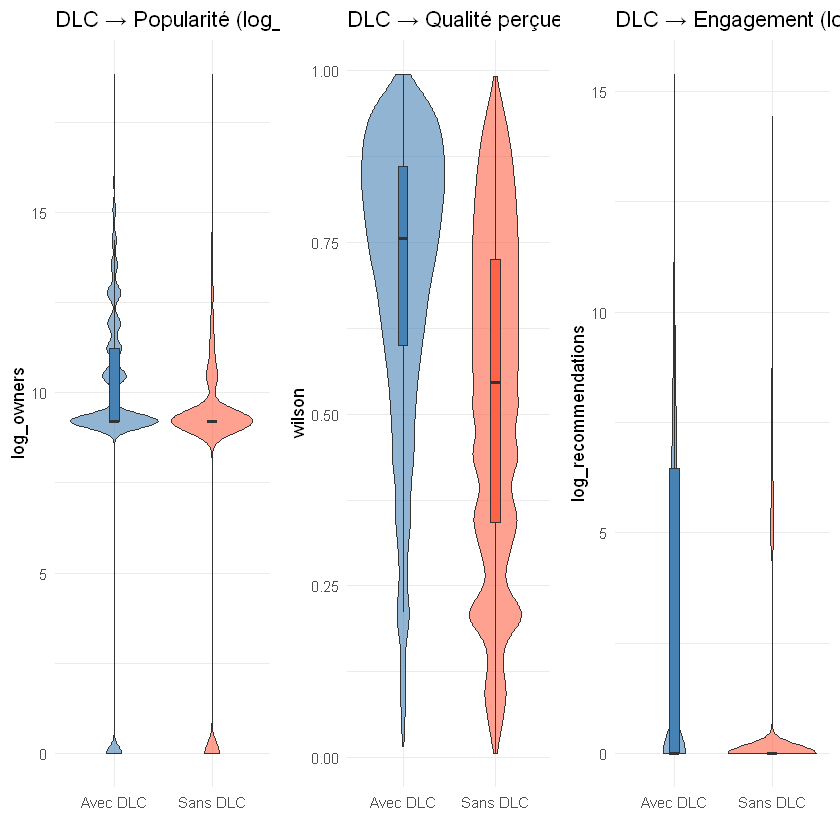

In [ ]:
df_analysis <- df_clean %>%
  mutate(
    has_dlc = `DLC count` > 0,
    price_group = case_when(
      Price == 0 ~ "Gratuit",
      Price < 5  ~ "< 5e",
      Price < 15 ~ "5-15e",
      Price < 30 ~ "15-30e",
      TRUE       ~ "+30e"
    ) %>% factor(levels = c("Gratuit", "< 5e", "5-15e", "15-30e", "+30e"))
  )

plot_binary_vs_success <- function(data, binary_var, success_var, 
                                    label_true, label_false, title) {
  data %>%
    filter(!is.na(.data[[success_var]]), !is.na(.data[[binary_var]])) %>%
    mutate(group = ifelse(.data[[binary_var]], label_true, label_false)) %>%
    ggplot(aes(x = group, y = .data[[success_var]], fill = group)) +
    geom_violin(alpha = 0.6) +
    geom_boxplot(width = 0.1, outlier.shape = NA) +
    scale_fill_manual(values = c("steelblue", "tomato")) +
    labs(title = title, x = "", y = success_var) +
    theme_minimal() +
    theme(legend.position = "none") 
}

p1a <- plot_binary_vs_success(df_analysis, "has_dlc", "log_owners",
                               "Avec DLC", "Sans DLC",
                               "DLC → Popularité (log_owners)")
p1b <- plot_binary_vs_success(df_analysis, "has_dlc", "wilson",
                               "Avec DLC", "Sans DLC",
                               "DLC → Qualité perçue (wilson)")
p1c <- plot_binary_vs_success(df_analysis, "has_dlc", "log_recommendations",
                               "Avec DLC", "Sans DLC",
                               "DLC → Engagement (log_recommendations)")

gridExtra::grid.arrange(p1a, p1b, p1c, ncol = 3)

# Tests statistiques
wilcox.test(log_owners ~ has_dlc, data = df_analysis)
wilcox.test(wilson ~ has_dlc, data = df_analysis)
wilcox.test(log_recommendations ~ has_dlc, data = df_analysis)

La présence de DLC est significativement associée aux trois composantes du succès (p < 2.2e-16). L'effet le plus marqué concerne la qualité perçue, les jeux avec DLC affichent un Wilson Score plus élevé et moins dispersé, laisse penser qu'ils proviennent de studios plus établis produisant des jeux mieux reçus. Cet effet est probablement indirect : Les jeux a succès font des DLC pour profiter encore plus de ce succès plutôt que les jeux font succès car ils possèdent un DLC, c'est un lien de causalité inversé.

Warning message:
“Removed 33644 rows containing non-finite outside the scale range
(`stat_ydensity()`).”
Warning message:
“Removed 33644 rows containing non-finite outside the scale range
(`stat_boxplot()`).”


dlc_group,wilson_median,owners_median,recomm_median,n
<fct>,<dbl>,<dbl>,<dbl>,<int>
0 DLC,0.5458917,9.21044,0.000000,95519
1-5 DLC,0.7529600,9.21044,0.000000,16145
6-10 DLC,0.7751476,11.22526,6.346402,786
11-100 DLC,0.7885430,11.91840,7.105376,638
100+ DLC,0.8192883,13.52783,7.944137,33



	Kruskal-Wallis rank sum test

data:  wilson by dlc_group
Kruskal-Wallis chi-squared = 6499.3, df = 4, p-value < 2.2e-16



	Kruskal-Wallis rank sum test

data:  log_owners by dlc_group
Kruskal-Wallis chi-squared = 5330.7, df = 4, p-value < 2.2e-16


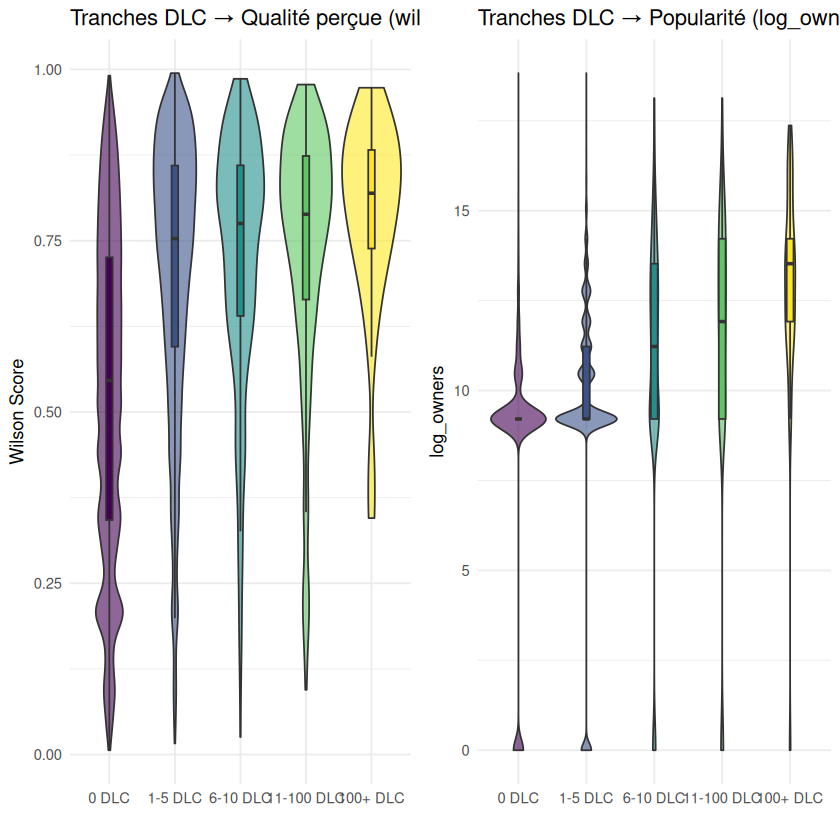

In [ ]:
df_analysis <- df_analysis %>%
  mutate(dlc_group = case_when(
    `DLC count` == 0        ~ "0 DLC",
    `DLC count` <= 5        ~ "1-5 DLC",
    `DLC count` <= 10       ~ "6-10 DLC",
    `DLC count` <= 100      ~ "11-100 DLC",
    TRUE                    ~ "100+ DLC"
  ) %>% factor(levels = c("0 DLC", "1-5 DLC", "6-10 DLC", "11-100 DLC", "100+ DLC")))

# Wilson par tranche DLC
p_dlc_wilson <- ggplot(df_analysis, aes(x = dlc_group, y = wilson, fill = dlc_group)) +
  geom_violin(alpha = 0.6) +
  geom_boxplot(width = 0.1, outlier.shape = NA) +
  scale_fill_viridis_d() +
  labs(title = "Tranches DLC → Qualité perçue (wilson)", x = "", y = "Wilson Score") +
  theme_minimal() +
  theme(legend.position = "none")

# log_owners par tranche DLC
p_dlc_owners <- ggplot(df_analysis, aes(x = dlc_group, y = log_owners, fill = dlc_group)) +
  geom_violin(alpha = 0.6) +
  geom_boxplot(width = 0.1, outlier.shape = NA) +
  scale_fill_viridis_d() +
  labs(title = "Tranches DLC → Popularité (log_owners)", x = "", y = "log_owners") +
  theme_minimal() +
  theme(legend.position = "none")

gridExtra::grid.arrange(p_dlc_wilson, p_dlc_owners, ncol = 2)

# Stats par groupe
df_analysis %>%
  group_by(dlc_group) %>%
  summarise(
    wilson_median    = median(wilson, na.rm = TRUE),
    owners_median    = median(log_owners, na.rm = TRUE),
    recomm_median    = median(log_recommendations, na.rm = TRUE),
    n = n()
  )

kruskal.test(wilson ~ dlc_group, data = df_analysis)
kruskal.test(log_owners ~ dlc_group, data = df_analysis)

Avoir ou ne pas avoir de DLC ne change pas la popularité, c'est seulement à partir de +6 DLC que le saut apparaît. Ce qui confirme bien notre causalité inversée.

## Prix : Exploration descriptive détaillée

**Résumé des résultats statistiques**: Test Kruskal-Wallis robuste en section "Analyses des facteurs associés au succès".



	Kruskal-Wallis rank sum test

data:  log_owners by price_group
Kruskal-Wallis chi-squared = 6138.7, df = 4, p-value < 2.2e-16



	Kruskal-Wallis rank sum test

data:  wilson by price_group
Kruskal-Wallis chi-squared = 1399.4, df = 4, p-value < 2.2e-16



	Kruskal-Wallis rank sum test

data:  log_recommendations by price_group
Kruskal-Wallis chi-squared = 6119.6, df = 4, p-value < 2.2e-16


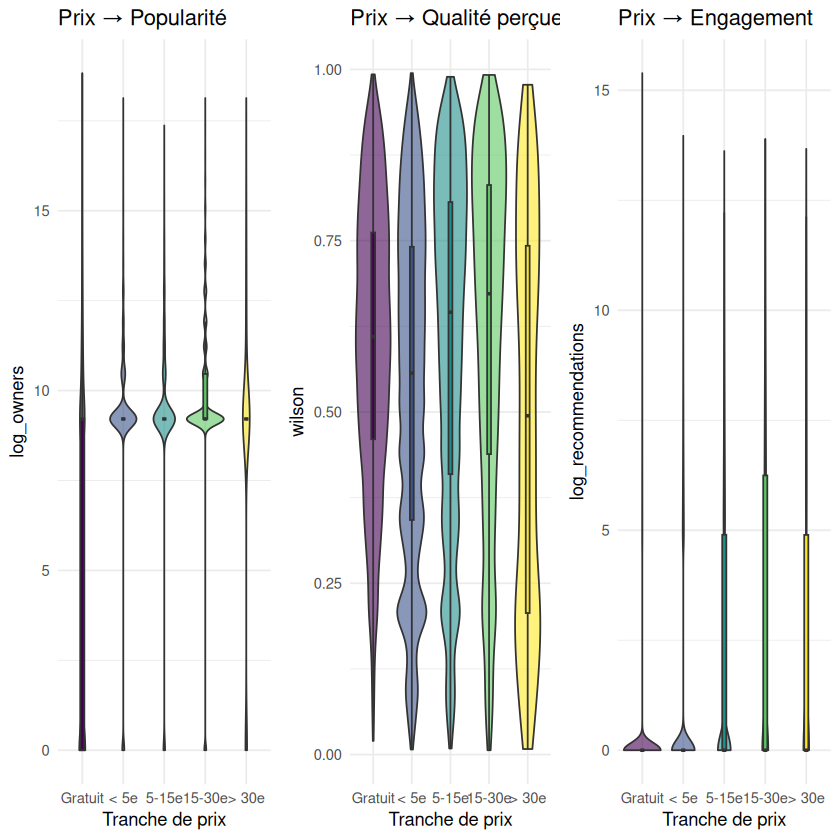

In [ ]:
# Visualisation par groupe de prix
plot_price <- function(success_var, title) {
  df_analysis %>%
    filter(!is.na(.data[[success_var]])) %>%
    ggplot(aes(x = price_group, y = .data[[success_var]], fill = price_group)) +
    geom_violin(alpha = 0.6) +
    geom_boxplot(width = 0.1, outlier.shape = NA) +
    scale_fill_viridis_d() +
    labs(title = title, x = "Tranche de prix", y = success_var) +
    theme_minimal() +
    theme(legend.position = "none")
}

p2a <- plot_price("log_owners", "Prix → Popularité")
p2b <- plot_price("wilson", "Prix → Qualité perçue")
p2c <- plot_price("log_recommendations", "Prix → Engagement")

gridExtra::grid.arrange(p2a, p2b, p2c, ncol = 3)

# Test Kruskal-Wallis (variable catégorielle)
kruskal.test(log_owners ~ price_group, data = df_analysis)
kruskal.test(wilson ~ price_group, data = df_analysis)
kruskal.test(log_recommendations ~ price_group, data = df_analysis)

Le prix est significativement associé à la qualité perçue (wilson) mais peu à la popularité brute (log_owners). Les jeux premium (+ de 30e) affichent un Wilson Score systématiquement plus élevé, qui laisse penser à un effet de sélection : les joueurs qui investissent davantage sont plus exigeants dans leurs choix et donc plus satisfaits. À l'inverse, la gratuité maximise l'accessibilité sans garantir la satisfaction. Le LASSO attribue un coefficient négatif au prix, cohérent avec l'effet : un jeu gratuit touche plus de joueurs même si sa qualité perçue est moins bonne.

On peut aussi s'intéresser à la relation inverse :

wilson_group,prix_median,prix_moyen,n
<fct>,<dbl>,<dbl>,<int>
< 0.60,2.99,5.410252,37246
0.60-0.75,3.49,5.357206,14802
0.75-0.90,3.99,5.915675,14747
> 0.90,4.99,7.067612,4417


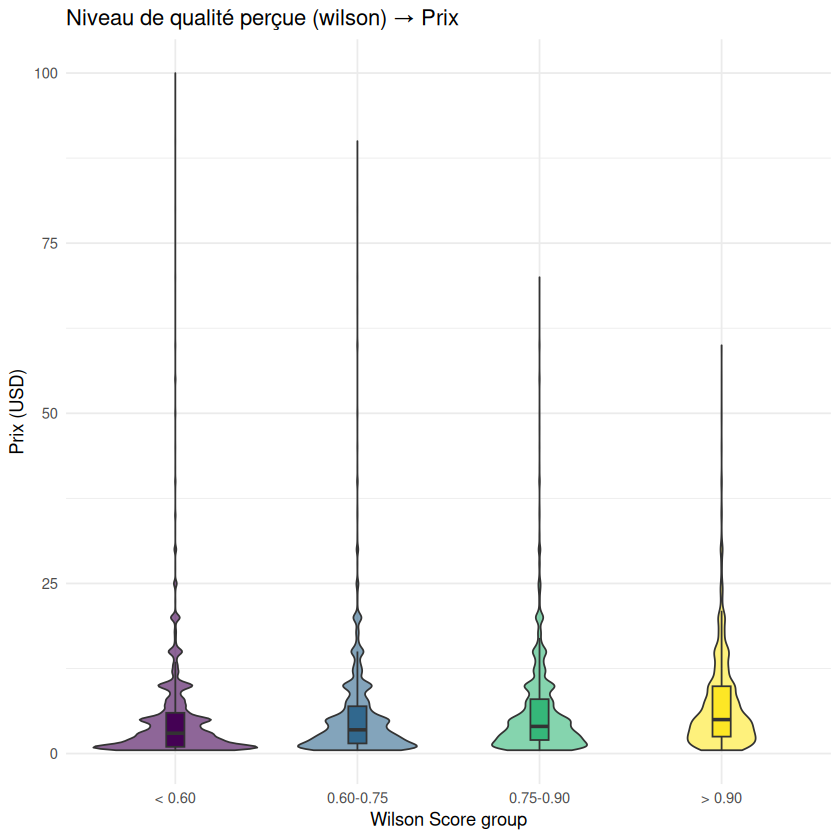

In [ ]:
df_analysis %>%
  filter(!is.na(wilson), Price > 0) %>%
  mutate(wilson_group = case_when(
    wilson < 0.6  ~ "< 0.60",
    wilson < 0.75 ~ "0.60-0.75",
    wilson < 0.90 ~ "0.75-0.90",
    TRUE          ~ "> 0.90"
  ) %>% factor(levels = c("< 0.60", "0.60-0.75", "0.75-0.90", "> 0.90"))) %>%
  group_by(wilson_group) %>%
  summarise(
    prix_median = median(Price, na.rm = TRUE),
    prix_moyen  = mean(Price, na.rm = TRUE),
    n = n()
  )

# Visualisation
df_analysis %>%
  filter(!is.na(wilson), Price > 0, Price < 100) %>%
  mutate(wilson_group = case_when(
    wilson < 0.6  ~ "< 0.60",
    wilson < 0.75 ~ "0.60-0.75",
    wilson < 0.90 ~ "0.75-0.90",
    TRUE          ~ "> 0.90"
  ) %>% factor(levels = c("< 0.60", "0.60-0.75", "0.75-0.90", "> 0.90"))) %>%
  ggplot(aes(x = wilson_group, y = Price, fill = wilson_group)) +
  geom_violin(alpha = 0.6) +
  geom_boxplot(width = 0.1, outlier.shape = NA) +
  scale_fill_viridis_d() +
  labs(title = "Niveau de qualité perçue (wilson)  Prix",
       x = "Wilson Score group", y = "Prix (USD)") +
  theme_minimal() +
  theme(legend.position = "none")

Les jeux mieux perçus sont légèrement plus chers (médiane 4.99e vs 2.99e) pour les moins bien notés, mais l'effet reste modeste, la qualité perçue n'est pas un déterminant fort du prix sur Steam, la majorité des jeux sont très peu chers indépendamment de leur qualité.

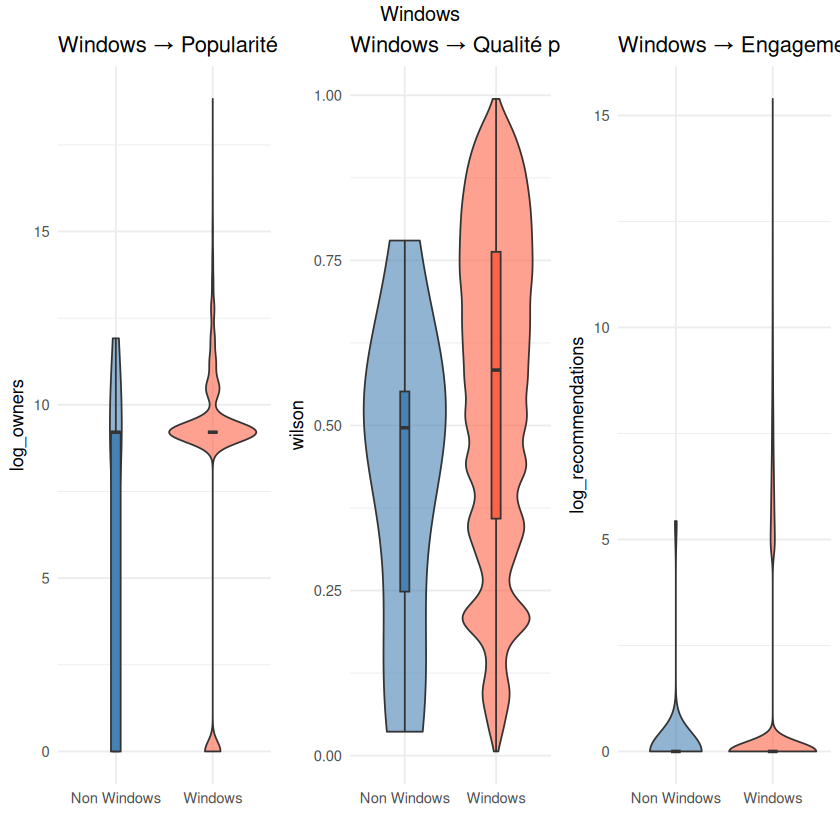

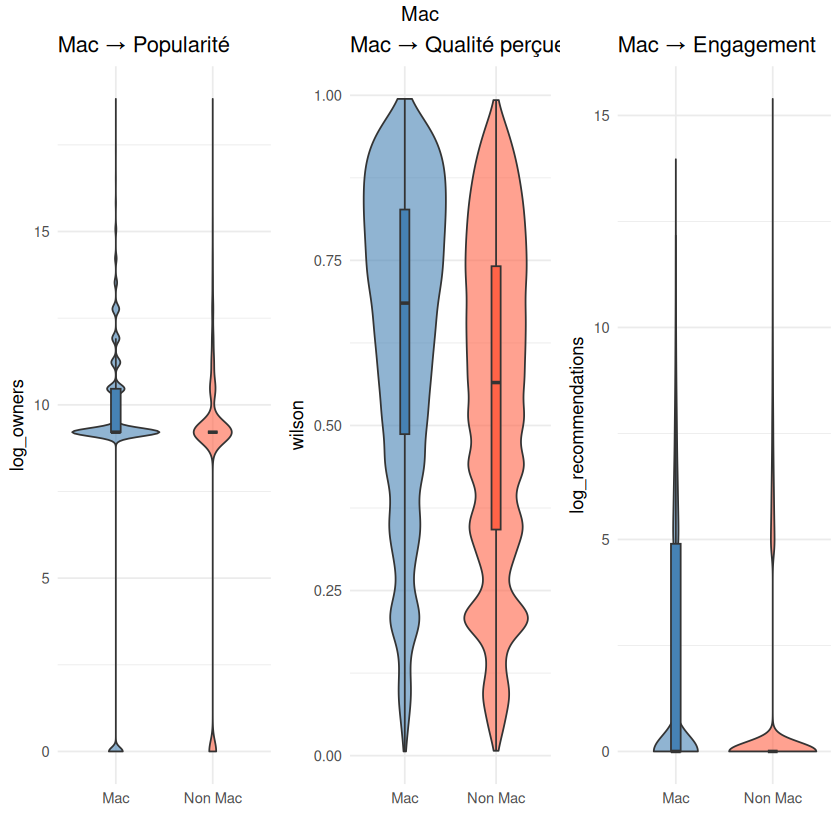

=== WINDOWS ===



	Wilcoxon rank sum test with continuity correction

data:  log_owners by Windows
W = 1216525, p-value = 0.001464
alternative hypothesis: true location shift is not equal to 0



	Wilcoxon rank sum test with continuity correction

data:  wilson by Windows
W = 269924, p-value = 0.07903
alternative hypothesis: true location shift is not equal to 0



	Wilcoxon rank sum test with continuity correction

data:  log_recommendations by Windows
W = 1439468, p-value = 0.033
alternative hypothesis: true location shift is not equal to 0


=== MAC ===


...

=== LINUX ===



	Wilcoxon rank sum test with continuity correction

data:  log_owners by Linux
W = 691744576, p-value < 2.2e-16
alternative hypothesis: true location shift is not equal to 0



	Wilcoxon rank sum test with continuity correction

data:  wilson by Linux
W = 303310150, p-value < 2.2e-16
alternative hypothesis: true location shift is not equal to 0



	Wilcoxon rank sum test with continuity correction

data:  log_recommendations by Linux
W = 695715978, p-value < 2.2e-16
alternative hypothesis: true location shift is not equal to 0


Windows_owners_med,Windows_wilson_med,Windows_recomm_med,Mac_owners_med,Mac_wilson_med,Mac_recomm_med,Linux_owners_med,Linux_wilson_med,Linux_recomm_med
<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
9.21044,0.5838848,0,9.21044,0.6853073,0,9.21044,0.6804971,0


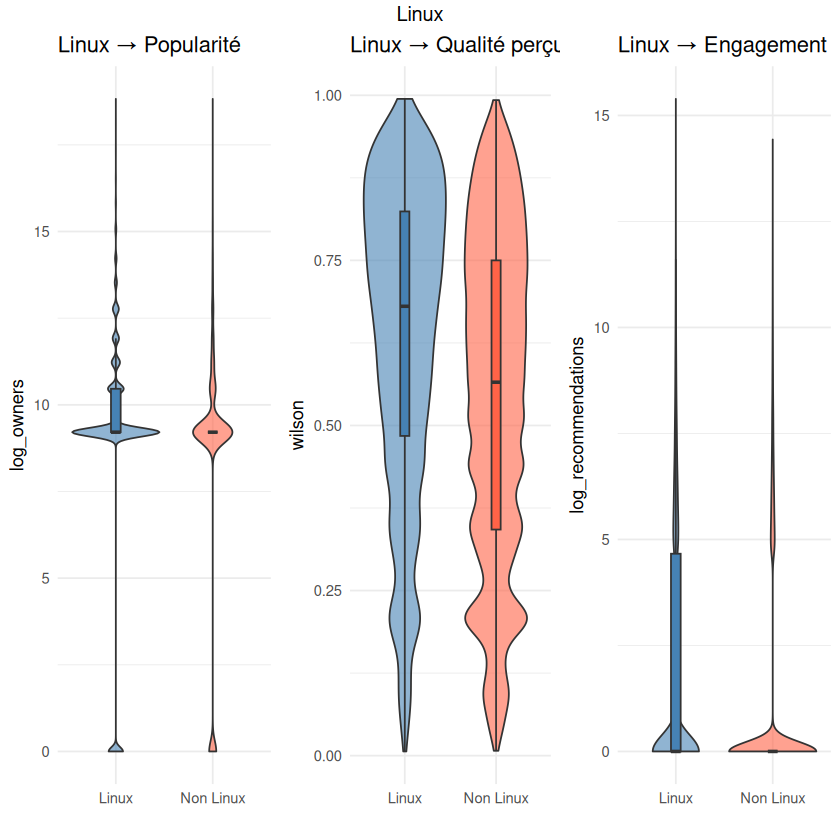

In [ ]:
# Support OS (Windows / Mac / Linux) : Exploration descriptive détaillée

# **Résumé des résultats robustes**: Tests Wilcoxon indépendants en section "Analyses des facteurs associés au succès".
# Cette section explore comment chaque OS affecte les composantes du score séparément.

# Support OS vs success_score DIRECT (résultats robustes)
cat("=== TESTS ROBUSTES (success_score complet) ===\n")
cat("WINDOWS:\n")
print(wilcox.test(success_score ~ Windows, data = df_analysis))
cat("\nMAC:\n")
print(wilcox.test(success_score ~ Mac, data = df_analysis))
cat("\nLINUX:\n")
print(wilcox.test(success_score ~ Linux, data = df_analysis))

# ============= EXPLORATIONS DESCRIPTIVES (composantes séparées) =============
# Support OS vs composantes du succès

Le support Mac et Linux est significativement associé aux trois composantes du succès. Cependant même conclusion que pour les DLC, ce sont les studios disposant de ressources suffisantes donc déjà populaires qui investissent dans le portage multiplateforme. Le support multiplateforme est plus un indicateur de "maturité" du studio qu'un levier direct de succès, c'est cohérent avec son coefficient positif mais faible dans le LASSO.

## Screenshots : Exploration descriptive détaillée

**Résumé des résultats robustes**: Test Wilcoxon robuste en section "Analyses des facteurs associés au succès".

Note: Seulement 60 jeux (~0.05%) sans screenshots. L'effet est probablement un indicateur de jeux abandonnés plutôt qu'un vrai levier de succès.


	Wilcoxon rank sum test with continuity correction

data:  log_owners by has_screenshots
W = 2908848, p-value = 0.02352
alternative hypothesis: true location shift is not equal to 0


	Wilcoxon rank sum test with continuity correction

data:  wilson by has_screenshots
W = 790285, p-value = 7.795e-05
alternative hypothesis: true location shift is not equal to 0


	Wilcoxon rank sum test with continuity correction

data:  log_recommendations by has_screenshots
W = 2951178, p-value = 0.009699
alternative hypothesis: true location shift is not equal to 0



has_screenshots,log_owners_med,wilson_med,recomm_med,n
<dbl>,<dbl>,<dbl>,<dbl>,<int>
0,9.21044,0.3994886,0,60
1,9.21044,0.5839783,0,113061


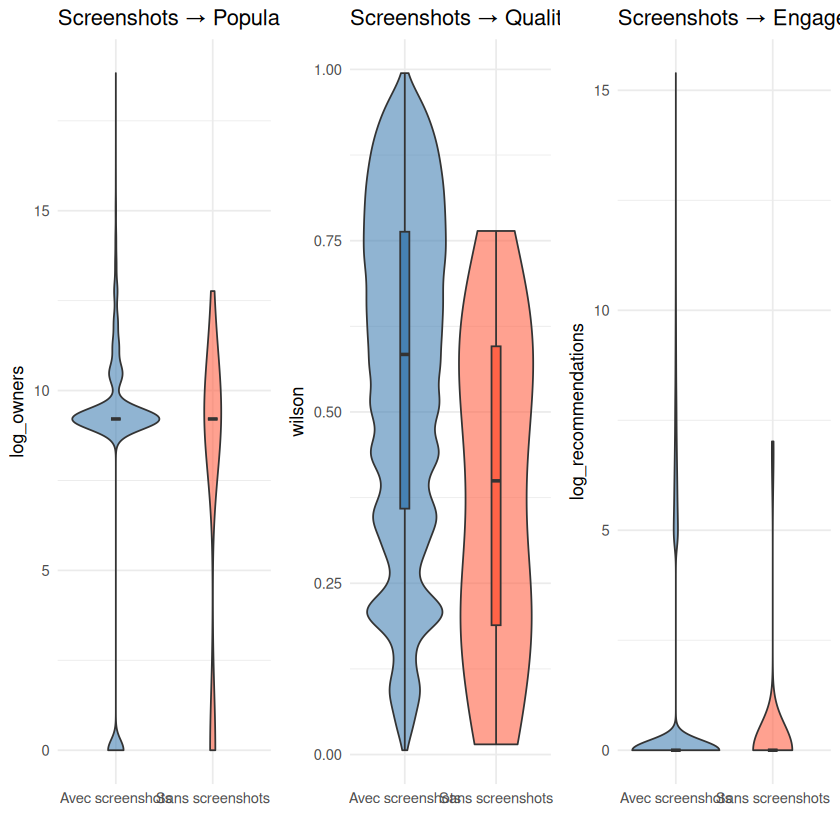

In [ ]:
# Screenshots vs composantes du succès
p_sc_owners <- plot_binary_vs_success(df_analysis, "has_screenshots", "log_owners",
                               "Avec screenshots", "Sans screenshots",
                               "Screenshots → Popularité")
p_sc_wilson <- plot_binary_vs_success(df_analysis, "has_screenshots", "wilson",
                               "Avec screenshots", "Sans screenshots",
                               "Screenshots → Qualité perçue")
p_sc_recomm <- plot_binary_vs_success(df_analysis, "has_screenshots", "log_recommendations",
                               "Avec screenshots", "Sans screenshots",
                               "Screenshots → Engagement")

gridExtra::grid.arrange(p_sc_owners, p_sc_wilson, p_sc_recomm, ncol = 3)

# Tests
print(wilcox.test(log_owners ~ has_screenshots, data = df_analysis))
print(wilcox.test(wilson ~ has_screenshots, data = df_analysis))
print(wilcox.test(log_recommendations ~ has_screenshots, data = df_analysis))

# Médianes
df_analysis %>%
  group_by(has_screenshots) %>%
  summarise(
    log_owners_med = median(log_owners, na.rm = TRUE),
    wilson_med     = median(wilson, na.rm = TRUE),
    recomm_med     = median(log_recommendations, na.rm = TRUE),
    n = n()
  )

La présence de screenshots est associée à une meilleure qualité perçue (wilson 0.58 vs 0.39, p=7.8e-05) mais sans effet sur la popularité. Cependant avec seulement 60 jeux sans screenshots sur 113 000, le résultat n'est pas réellement interprétable. Les jeux sans screenshots sont quasi inexistants sur Steam, l'absence de screenshots est plus un signal de jeu abandonné ou non maintenu plûtot qu'une mauvaise performance.

## Langues Audio & Texte : Exploration descriptive détaillée

**Résumé des résultats robustes**: Tests Kruskal-Wallis robustes en section "Analyses des facteurs associés au succès".


In [ ]:
# 1. Distribution pour choisir les tranches
summary(df_analysis$nb_languages)
quantile(df_analysis$nb_languages, probs = c(0.25, 0.5, 0.75, 0.90, 0.95), na.rm = TRUE)

summary(df_analysis$nb_audio_languages)
quantile(df_analysis$nb_audio_languages, probs = c(0.25, 0.5, 0.75, 0.90, 0.95), na.rm = TRUE)

   Min. 1st Qu.  Median    Mean 3rd Qu.    Max. 
  1.000   1.000   1.000   5.596   5.000 103.000 

25% 50% 75% 90% 95% 
  1   1   5  11  17

Warning message:
“Unknown or uninitialised column: `nb_audio_languages`.”


Length  Class   Mode 
     0   NULL   NULL 

Warning message:
“Unknown or uninitialised column: `nb_audio_languages`.”


25% 50% 75% 90% 95% 
 NA  NA  NA  NA  NA

In [ ]:
# Recréer nb_audio_languages dans df_analysis
df_analysis <- df_analysis %>%
  mutate(
    nb_audio_languages = str_count(`Full audio languages`, ",") + 1,
    nb_audio_languages = ifelse(`Full audio languages` == "[]" | 
                                 is.na(`Full audio languages`), 0, 
                                 nb_audio_languages),
    has_multi_audio = nb_audio_languages > 1
  )

# Vérification distributions
cat("=== LANGUES TEXTE ===\n")
summary(df_analysis$nb_languages)
quantile(df_analysis$nb_languages, probs = c(0.25, 0.5, 0.75, 0.90, 0.95), na.rm = TRUE)

cat("\n=== LANGUES AUDIO ===\n")
summary(df_analysis$nb_audio_languages)
quantile(df_analysis$nb_audio_languages, probs = c(0.25, 0.5, 0.75, 0.90, 0.95), na.rm = TRUE)

=== LANGUES TEXTE ===


   Min. 1st Qu.  Median    Mean 3rd Qu.    Max. 
  1.000   1.000   1.000   5.596   5.000 103.000 

25% 50% 75% 90% 95% 
  1   1   5  11  17


=== LANGUES AUDIO ===


   Min. 1st Qu.  Median    Mean 3rd Qu.    Max. 
  0.000   0.000   0.000   1.986   1.000 103.000 

25% 50% 75% 90% 95% 
  0   0   1   2   3

Warning message:
"Removed 33643 rows containing non-finite outside the scale range
(`stat_ydensity()`)."
Warning message:
"Removed 33643 rows containing non-finite outside the scale range
(`stat_boxplot()`)."
Warning message:
"Removed 33643 rows containing non-finite outside the scale range
(`stat_ydensity()`)."
Warning message:
"Removed 33643 rows containing non-finite outside the scale range
(`stat_boxplot()`)."


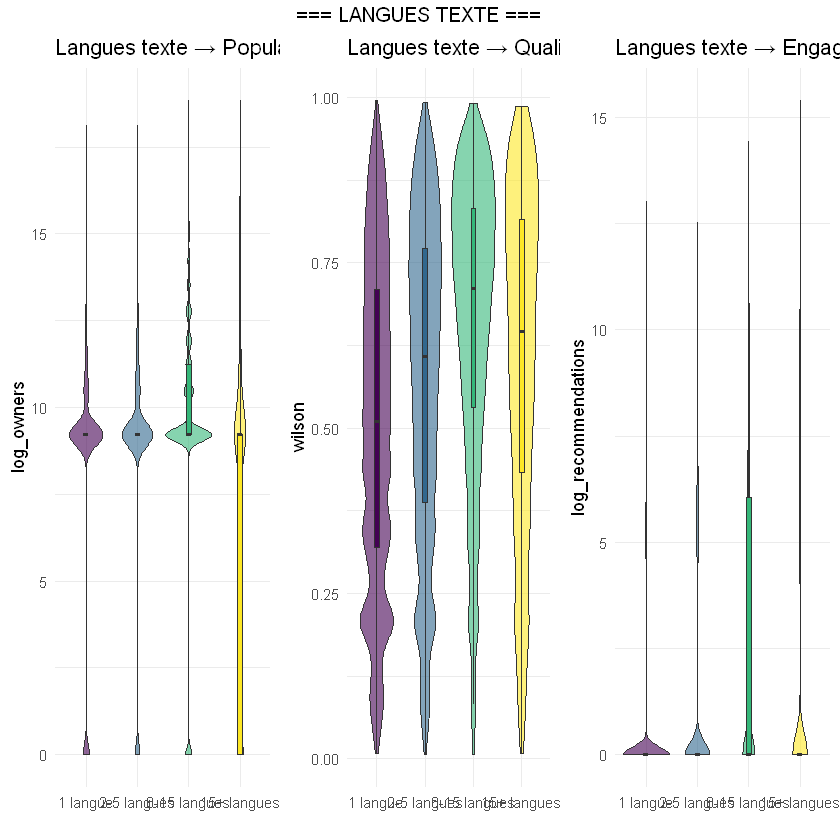

LANGUES TEXTE

	Kruskal-Wallis rank sum test

data:  log_owners by lang_group
Kruskal-Wallis chi-squared = 3852.2, df = 3, p-value < 2.2e-16


	Kruskal-Wallis rank sum test

data:  wilson by lang_group
Kruskal-Wallis chi-squared = 4666.4, df = 3, p-value < 2.2e-16


	Kruskal-Wallis rank sum test

data:  log_recommendations by lang_group
Kruskal-Wallis chi-squared = 11229, df = 3, p-value < 2.2e-16


LANGUES AUDIO

	Kruskal-Wallis rank sum test

data:  log_owners by audio_group
Kruskal-Wallis chi-squared = 1751.7, df = 3, p-value < 2.2e-16


	Kruskal-Wallis rank sum test

data:  wilson by audio_group
Kruskal-Wallis chi-squared = 2185.8, df = 3, p-value < 2.2e-16


	Kruskal-Wallis rank sum test

data:  log_recommendations by audio_group
Kruskal-Wallis chi-squared = 6690.6, df = 3, p-value < 2.2e-16


MEDIANES LANGUES TEXTE
# A tibble: 4 × 5
  lang_group   log_owners_med wilson_med recomm_med     n
  <fct>                 <dbl>      <dbl>      <dbl> <int>
1 1 langue               9.21    

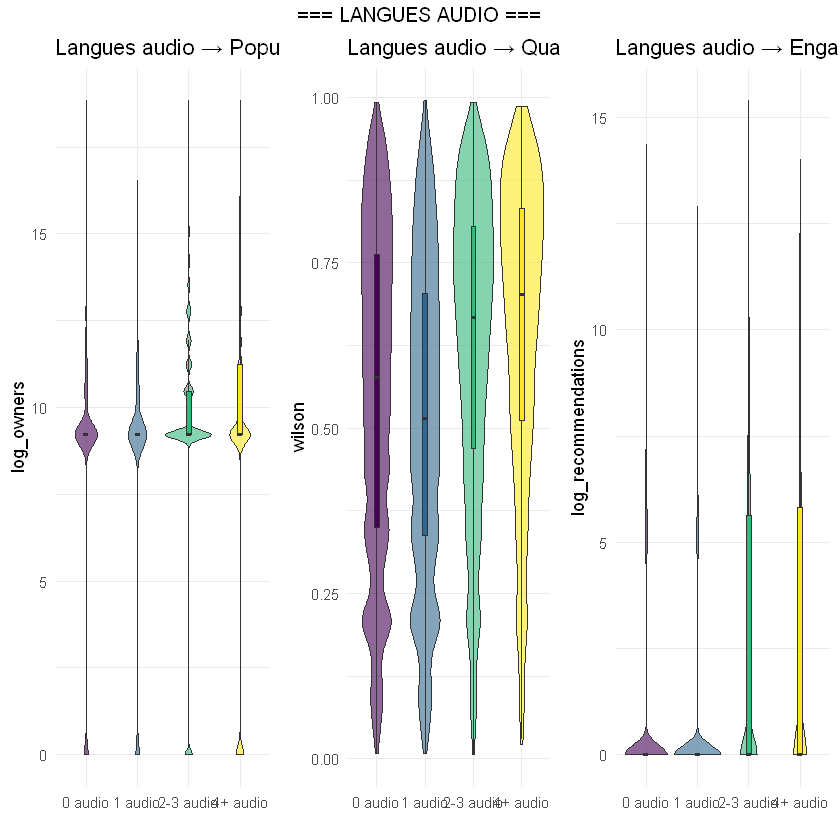

In [20]:
# Créer les groupes
df_analysis <- df_analysis %>%
  mutate(
    lang_group = case_when(
      nb_languages == 1  ~ "1 langue",
      nb_languages <= 5  ~ "2-5 langues",
      nb_languages <= 15 ~ "6-15 langues",
      TRUE               ~ "15+ langues"
    ) %>% factor(levels = c("1 langue", "2-5 langues", "6-15 langues", "15+ langues")),
    
    audio_group = case_when(
      nb_audio_languages == 0 ~ "0 audio",
      nb_audio_languages == 1 ~ "1 audio",
      nb_audio_languages <= 3 ~ "2-3 audio",
      TRUE                    ~ "4+ audio"
    ) %>% factor(levels = c("0 audio", "1 audio", "2-3 audio", "4+ audio"))
  )

# === LANGUES TEXTE ===
p_lt_owners <- ggplot(df_analysis, aes(x = lang_group, y = log_owners, fill = lang_group)) +
  geom_violin(alpha = 0.6) + geom_boxplot(width = 0.1, outlier.shape = NA) +
  scale_fill_viridis_d() +
  labs(title = "Langues texte → Popularité", x = "", y = "log_owners") +
  theme_minimal() + theme(legend.position = "none")

p_lt_wilson <- ggplot(df_analysis, aes(x = lang_group, y = wilson, fill = lang_group)) +
  geom_violin(alpha = 0.6) + geom_boxplot(width = 0.1, outlier.shape = NA) +
  scale_fill_viridis_d() +
  labs(title = "Langues texte → Qualité perçue", x = "", y = "wilson") +
  theme_minimal() + theme(legend.position = "none")

p_lt_recomm <- ggplot(df_analysis, aes(x = lang_group, y = log_recommendations, fill = lang_group)) +
  geom_violin(alpha = 0.6) + geom_boxplot(width = 0.1, outlier.shape = NA) +
  scale_fill_viridis_d() +
  labs(title = "Langues texte → Engagement", x = "", y = "log_recommendations") +
  theme_minimal() + theme(legend.position = "none")

gridExtra::grid.arrange(p_lt_owners, p_lt_wilson, p_lt_recomm, ncol = 3,
                        top = "=== LANGUES TEXTE ===")

# LANGUES AUDIO 
p_la_owners <- ggplot(df_analysis, aes(x = audio_group, y = log_owners, fill = audio_group)) +
  geom_violin(alpha = 0.6) + geom_boxplot(width = 0.1, outlier.shape = NA) +
  scale_fill_viridis_d() +
  labs(title = "Langues audio → Popularité", x = "", y = "log_owners") +
  theme_minimal() + theme(legend.position = "none")

p_la_wilson <- ggplot(df_analysis, aes(x = audio_group, y = wilson, fill = audio_group)) +
  geom_violin(alpha = 0.6) + geom_boxplot(width = 0.1, outlier.shape = NA) +
  scale_fill_viridis_d() +
  labs(title = "Langues audio → Qualité perçue", x = "", y = "wilson") +
  theme_minimal() + theme(legend.position = "none")

p_la_recomm <- ggplot(df_analysis, aes(x = audio_group, y = log_recommendations, fill = audio_group)) +
  geom_violin(alpha = 0.6) + geom_boxplot(width = 0.1, outlier.shape = NA) +
  scale_fill_viridis_d() +
  labs(title = "Langues audio → Engagement", x = "", y = "log_recommendations") +
  theme_minimal() + theme(legend.position = "none")

gridExtra::grid.arrange(p_la_owners, p_la_wilson, p_la_recomm, ncol = 3,
                        top = "=== LANGUES AUDIO ===")

#TESTS STATISTIQUES
cat("LANGUES TEXTE\n")
print(kruskal.test(log_owners ~ lang_group, data = df_analysis))
print(kruskal.test(wilson ~ lang_group, data = df_analysis))
print(kruskal.test(log_recommendations ~ lang_group, data = df_analysis))

cat("\nLANGUES AUDIO\n")
print(kruskal.test(log_owners ~ audio_group, data = df_analysis))
print(kruskal.test(wilson ~ audio_group, data = df_analysis))
print(kruskal.test(log_recommendations ~ audio_group, data = df_analysis))

# === MEDIANES ===
cat("\nMEDIANES LANGUES TEXTE\n")
df_analysis %>%
  group_by(lang_group) %>%
  summarise(
    log_owners_med = median(log_owners, na.rm = TRUE),
    wilson_med     = median(wilson, na.rm = TRUE),
    recomm_med     = median(log_recommendations, na.rm = TRUE),
    n = n()
  ) %>% print()

cat("\nMEDIANES LANGUES AUDIO\n")
df_analysis %>%
  group_by(audio_group) %>%
  summarise(
    log_owners_med = median(log_owners, na.rm = TRUE),
    wilson_med     = median(wilson, na.rm = TRUE),
    recomm_med     = median(log_recommendations, na.rm = TRUE),
    n = n()
  ) %>% print()

Langues texte : la baisse à 15+ langues (0.711 → 0.646) se relève. Les jeux avec énormément de langues ne sont pas forcément les mieux perçus, probablement des jeux qui investissent dans la localisation mais pas dans la qualité du jeu lui-même.
Langues audio : le groupe "0 audio" a un wilson plus élevé (0.577) que "1 audio" (0.515). Un jeu sans aucun audio du tout peut quand même être bien perçu, typiquement les jeux de puzzle, stratégie, casual.

Même conclusion qu'OS et DLC sur la causalité

Le nombre de langues supportées est significativement associé à la qualité perçue (p < 2.2e-16) mais sans effet sur la popularité, log_owners reste identique (9.21) quel que soit le nombre de langues. L'effet de seuil observé pour les langues texte (baisse au-delà de 15 langues) peut montrer que la localisation abusive ne compense pas une qualité insuffisante. Comme pour le support multiplateforme, le nombre de langues reflète plus les ressources du studio que l'attractivité du jeu.

# Conclusions et synthèse

## Validité du success_score

Validation réussie :
- ACP : Variance expliquée par PC1 (première composante principale)
- Clustering : Identification de profils naturels de jeux
- Robustesse : Stabilité du score même avec des poids différents

Le score créé (0.5 * log_owners + 0.3 * log_recommendations + 0.2 * wilson) capture bien une dimension réelle du succès commercial.

## Résultats principaux

Voir section "Analyses des facteurs associés au succès" 

## Note importante

La causalité reste difficile sans données temporelles ou expérience.
